# Array-Oriented Programming with Arrays

Using NumPy array enables you to express many kinds of data processing tasks as concise array expressions that might otherwise require writing loops. This practice of replacing explicit loops with array expressions is reffered to by some people as *vectorization*. In general, vectorized array operations will usually be signficantly faster than their pure Python equivalents, with the biggest impact in any kind of numerical computations. 

As a simple example, suppose we wished to evaluate the function ``sqrt(x^2 + y^2)`` across a regular grid of values. The ``numpy.meshgrid`` functions takes two one-dimensional arrays and produces two two-dimensional matrices correspinding to all pairs of ``(x, y)`` in the two arrays: 

In [45]:
import numpy as np 

points = np.arange(-5, 5, 0.01) # 100 equally spaced points

xs, ys = np.meshgrid(points, points)

In [46]:
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]],
      shape=(1000, 1000))

Evaluating the function is a matter of writing the same expresison you would write with two points:

In [47]:
z = np.sqrt(xs ** 2 + ys ** 2)

In [48]:
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]], shape=(1000, 1000))

To visualize this we can use ``matplotlib`` to show the two-dimensional array:

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/72/xf7wbb39361gc9hk7n78n1j00000gn/T/ipykernel_62896/3314429285.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

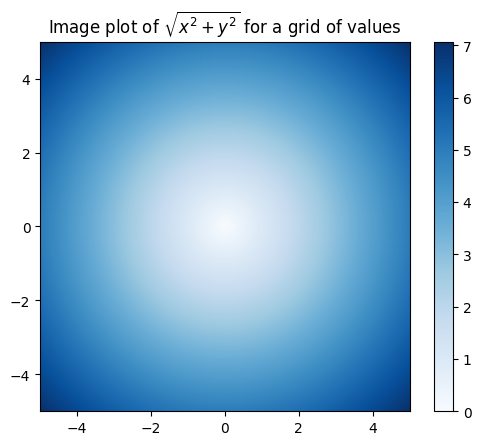

In [49]:
import matplotlib.pyplot as plt 

plt.imshow(z, cmap = plt.cm.Blues, extent=[-5, 5, -5, 5]),plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


## Expressing Conditional Logic as Array Operations

The ``numpy.where`` function is a vectorized version of the ternary expression ``x if condition else y``. Suppose we had a Boolean array and two arrays of values: 

In [50]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])

yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])

cond = np.array([True, False, True, True, False])

Suppose we wanted to take a value from ``xarr`` whenever the corresponding value in ``cond`` is ``True``, and otherwise take the value from ``yarr``. A list comprehension doing this might look like:

In [51]:
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]

result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

Not as efficient, you use instead do:

In [52]:
result = np.where(cond, xarr, yarr)

result 

array([1.1, 2.2, 1.3, 1.4, 2.5])

## Mathematical and Statistical Methods 

A set of mathemetical functions that compute statistics about an entire array or about the data along an axis are accessible as methods of the array class. You can use aggregations (sometimes called *reductions*) like ``sum``, ``mean`` and ``std`` either by calling the array instance method or using the top-level NumPy function. When you use the NumPy function, like ``numpy.sum``, you have to pass the array you want to aggregate as the first-argument. 

For example:

In [53]:
arr = np.random.standard_normal((5, 4))

arr

array([[ 0.40144982,  0.18474307,  0.26026144, -0.55936453],
       [-1.43613714,  0.7347583 ,  0.4123289 ,  0.73960892],
       [ 0.06490578, -1.23744504,  0.65198846, -1.46213841],
       [ 1.62074111,  0.41468259,  0.83509953, -0.05568722],
       [ 0.89390902,  0.33246244,  1.47223809,  0.28996394]])

In [54]:
arr.mean()

np.float64(0.22791845328188262)

In [55]:
np.mean(arr)

np.float64(0.22791845328188262)

In [56]:
arr.sum()

np.float64(4.5583690656376525)

Functions like ``sum`` and ``mean`` take an optional ``axis`` arguement that computes the statistic over the given axis, resulting in an array with one less dimension: 

In [57]:
arr.mean(axis=1)

array([ 0.07177245,  0.11263974, -0.49567231,  0.703709  ,  0.74714337])

In [58]:
arr.sum(axis=1)

array([ 0.2870898 ,  0.45055898, -1.98268922,  2.81483602,  2.98857349])

Here, ``arr.mean(axis = 1)`` means "compute mean across the columns", where ``arr.sum(axis=0)`` means "compute sum down the rows"